##Patch embeddings

 An image is (batch, channels, height, width) -> (batch, sequence_length, d_model) is what transformers expect

Each position in the 8×8 output corresponds to one 4×4 patch of the original image.

Stage	| Shape |	Meaning
1. Input |    	(B, 3, 32, 32) |	3 color channels, 32×32 pixels
2. After conv	| (B, 256, 8, 8) | 256 features at each of 8×8 patch positions
3. Flatten |    (B, 256, 64)   |	the 8×8 grid becomes a list of 64 patches
4. Transpose |  (B, 64, 256)	 | 64 tokens, each a 256-vector

In [1]:
import torch
import torch.nn as nn

In [2]:
class PatchEmbedding(nn.Module):
  def __init__(self, img_size=32, patch_size=4, in_channels=3, d_model=256):
    super().__init__()
    assert img_size % patch_size == 0, "image must divide evenly into patches"
    self.num_patches = (img_size // patch_size) ** 2
    self.proj = nn.Conv2d(in_channels, d_model, kernel_size=patch_size, stride=patch_size)  #(3, 256, h, w)

  def forward(self, x):
    x = self.proj(x)         #(B, d_model, H/P, W/P)
    x = x.flatten(2)         #(B, d_model, N)
    return x.transpose(1,2)  #(B, N, d_model)

In [3]:
x = torch.randn(2,3,32,32)
out = PatchEmbedding()(x)
print(out.shape)

torch.Size([2, 64, 256])


[CLS] token and positional embeddings

Shapes (CIFAR-10 setup):

1. Patch tokens: (B, 64, 256)
2. Class token, copied for each image: (B, 1, 256)
3. Concatenate along the sequence dimension: (B, 65, 256)
4. Positional embedding: (1, 65, 256), one vector per position, including the class token
5. Add them: (B, 65, 256). The leading 1 is broadcast across the batch, so every image gets the same position vectors.

In [4]:
class ViTEmbeddings(nn.Module):
  def __init__(self, img_size=32, patch_size=4, in_channels=3, d_model=256, dropout=0.1):
    super().__init__()
    self.patch_embed = PatchEmbedding(img_size=img_size,patch_size=patch_size,in_channels=in_channels,d_model=d_model)
    n = self.patch_embed.num_patches
    self.cls_token = nn.Parameter(torch.zeros(1,1,d_model))
    self.pos_embed = nn.Parameter(torch.zeros(1,n+1,d_model))
    nn.init.trunc_normal_(self.pos_embed, std=0.02)
    nn.init.trunc_normal_(self.cls_token, std=0.02)
    self.dropout = nn.Dropout(dropout)

  def forward(self, x):
    x = self.patch_embed(x)                       # (B, N, d_model)
    cls = self.cls_token.expand(x.size(0),-1,-1)  # (B, 1, d_model)
    x = torch.cat([cls, x], dim=1)                # (B, N+1, d_model)
    x = x + self.pos_embed                        # broadcast over batch
    return self.dropout(x)


In [5]:
x = torch.randn(2,3,32,32)
out = ViTEmbeddings()(x)
print(out.shape)

torch.Size([2, 65, 256])


## Multi headed Attention

In [6]:
def split_heads(x, h):
  batch, words, d_model = x.shape
  d_k = d_model // h
  x = x.view(batch, words, h, d_k)
  x = x.transpose(1,2)
  return x

In [7]:
def merge_heads(x):
  batch, h, words, d_k = x.shape
  x = x.transpose(1,2)
  x = x.contiguous().view(batch, words, h*d_k)
  return x

In [8]:
import math
def attention_mask(q,k,v,mask=None):
  d_k = q.size(-1)
  scores = q @ k.transpose(-2,-1)/math.sqrt(d_k)
  weights = scores.softmax(dim=-1) # dim - row wise
  return weights @ v, weights

In [9]:
class MultiheadedAttention(nn.Module):
  def __init__(self, h, d_model):
    super().__init__()
    self.h = h
    self.d_k = d_model // h
    self.w_q = nn.Linear(d_model, d_model)
    self.w_k = nn.Linear(d_model, d_model)
    self.w_v = nn.Linear(d_model, d_model)
    self.w_o = nn.Linear(d_model, d_model)

  def forward(self, query, key, value, mask=None):
    if mask is not None:
      mask = mask.unsqueeze(1)

    q = split_heads(self.w_q(query), self.h)
    k = split_heads(self.w_k(key), self.h)
    v = split_heads(self.w_v(value), self.h)

    out, weights = attention_mask(q,k,v,mask) # remember it outputs two things (earlier there was error)
    out = merge_heads(out)

    return self.w_o(out)

## Transformer (Encoder) Block

In [10]:
class ViTEncoderBlock(nn.Module):
  def __init__(self, d_model=256, n_heads=8, d_ff=1024, dropout=0.1):
    super().__init__()
    self.norm1 = nn.LayerNorm(d_model)
    self.attn = MultiheadedAttention(h=n_heads, d_model=d_model)
    self.norm2 = nn.LayerNorm(d_model)
    self.mlp = nn.Sequential(
        nn.Linear(d_model, d_ff),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(d_ff, d_model),
        nn.Dropout(dropout)
    )
    self.dropout = nn.Dropout(dropout)

  def forward(self, x, mask=None):
    h = self.norm1(x)
    x = x + self.dropout(self.attn(h,h,h))
    x = x + self.mlp(self.norm2(x))
    return x

## Transformer 6 Blocks

In [11]:
class ViTEncoder(nn.Module):
  def __init__(self, depth=6, d_model=256, n_heads=8, d_ff=1024, dropout=0.1):
    super().__init__()
    self.blocks = nn.ModuleList([                                #not a python list - only registers a layer's weights
          ViTEncoderBlock(d_model, n_heads, d_ff, dropout)
          for _ in range(depth)
    ])
    self.norm = nn.LayerNorm(d_model)

  def forward(self, x):
    for block in self.blocks:
      x = block(x)
    return self.norm(x)

In [12]:
x = torch.randn(2,65,256)
out = ViTEncoder()(x)
print(out.shape)

torch.Size([2, 65, 256])


## Classification head

Now we have 65 tokens per image, each token is expressed by 256 numbers

(B, 65, 256) ──► take index 0 ──► (B, 256) ──► Linear(256, 10) ──► (B, 10)

65 → 1 is a selection, with no math. x[:, 0] just picks out the class token's row and ignores the other 64. Nothing is learned or computed in this step. The class token can stand in for the whole image because, through all the attention layers, it has already gathered information from every patch.

256 → 10 is a learned linear layer. nn.Linear(256, 10) multiplies the 256 numbers by a 256 × 10 weight matrix (plus a bias) and produces 10 scores, one per CIFAR-10 class. Those weights are trained, so the model learns which combinations of the 256 features point to "cat," "ship," and so on.

In [13]:
class ClassificationHead(nn.Module):
  def __init__(self, d_model=256, num_classes=10):
    super().__init__()
    self.fc = nn.Linear(d_model, num_classes)

  def forward(self, x):
    cls_out = x[:, 0] #65 → 1 (B, 256) ->  x[:, 0]: only the cls token's 256 numbers remain
    return self.fc(cls_out) #(B, num_classes)

In [14]:
x = torch.randn(2, 65, 256)
out = ClassificationHead()(x)
print(out.shape)

torch.Size([2, 10])


## Assembling everything - > ViT

In [15]:
class ViT(nn.Module):
  def __init__(self, img_size=32, patch_size=4, in_channels=3, num_classes=10, d_model=256, depth=6, n_heads=8, d_ff=1024, dropout=0.1):
    super().__init__()
    self.embed = ViTEmbeddings(img_size=img_size, patch_size=patch_size, in_channels=in_channels, d_model=d_model, dropout=dropout)
    self.encoder = ViTEncoder(depth=depth, d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=dropout)
    self.head = ClassificationHead(d_model=d_model, num_classes=num_classes)

  def forward(self, x):
    x = self.embed(x)
    x = self.encoder(x)
    return self.head(x)

In [16]:
model = ViT()
x = torch.randn(2, 3, 32, 32)

out = model(x)
print(out.shape)

print(sum(p.numel() for p in model.parameters()))

labels = torch.tensor([3, 7])
loss = nn.CrossEntropyLoss()(out, labels)
loss.backward()
print(loss.item())

torch.Size([2, 10])
4771082
2.902845859527588


Verify:
The parameter count (4,771,082) is also exactly right.

1. Patch conv: 256 × 48 weights + 256 biases ->	12,544
2. Class token->	256
3. Position embedding: 65 × 256->	16,640
4. One encoder block (attention 263,168 + MLP 525,568 + 2 norms 1,024)->	789,760
5. 6 blocks->	4,738,560
6. Final LayerNorm	->512
7. Head: 256 × 10 + 10	->2,570
8. Total	->4,771,082

## Training the model on CIFAR-10

In [17]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

mean = (0.4914, 0.4822, 0.4465)   # CIFAR-10 per-channel statistics
std  = (0.2470, 0.2435, 0.2616)

train_tf = T.Compose([
    T.RandomCrop(32, padding=4),      # augmentation: random shifts
    T.RandomHorizontalFlip(),         # augmentation: mirror images
    T.ToTensor(),                     # PIL image -> (3, 32, 32) floats in [0,1]
    T.Normalize(mean, std),           # center and scale each channel
])
test_tf = T.Compose([T.ToTensor(), T.Normalize(mean, std)])  # no augmentation for test data but we have applied augmentation for train data

train_set = torchvision.datasets.CIFAR10("./data", train=True,  download=True,transform=train_tf)
test_set  = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=test_tf)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False, num_workers=2)

x, y = next(iter(train_loader))
print(x.shape, y.shape)

cuda


100%|██████████| 170M/170M [38:44<00:00, 73.3kB/s]


torch.Size([128, 3, 32, 32]) torch.Size([128])


In [18]:
model = ViT().to(device)

EPOCHS = 50
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.05)

steps_per_epoch = len(train_loader)
total_steps  = EPOCHS * steps_per_epoch
warmup_steps = 5 * steps_per_epoch

def lr_lambda(step):
    if step < warmup_steps:                                   # linear warmup
        return (step + 1) / warmup_steps
    progress = (step - warmup_steps) / (total_steps - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * progress))           # cosine decay to 0

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [19]:
def train_one_epoch(model, loader):
    model.train()                       # enables dropout
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # guards against spikes
        optimizer.step()
        scheduler.step()
        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        n += x.size(0)
    return total_loss / n, correct / n

@torch.no_grad()
def evaluate(model, loader):
    model.eval()                        # disables dropout
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        total_loss += criterion(out, y).item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        n += x.size(0)
    return total_loss / n, correct / n

In [20]:
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
best_acc = 0.0

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    te_loss, te_acc = evaluate(model, test_loader)

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss);  history["test_acc"].append(te_acc)

    if te_acc > best_acc:
        best_acc = te_acc
        torch.save(model.state_dict(), "vit_cifar10_best.pt")

    print(f"epoch {epoch+1:02d}/{EPOCHS} | "
          f"train loss {tr_loss:.3f} acc {tr_acc:.3f} | "
          f"test loss {te_loss:.3f} acc {te_acc:.3f}")

print("best test accuracy:", best_acc)

epoch 01/50 | train loss 1.978 acc 0.291 | test loss 1.850 acc 0.380
epoch 02/50 | train loss 1.709 acc 0.431 | test loss 1.645 acc 0.474
epoch 03/50 | train loss 1.572 acc 0.502 | test loss 1.507 acc 0.529
epoch 04/50 | train loss 1.524 acc 0.524 | test loss 1.464 acc 0.558
epoch 05/50 | train loss 1.514 acc 0.529 | test loss 1.469 acc 0.554
epoch 06/50 | train loss 1.482 acc 0.545 | test loss 1.500 acc 0.542
epoch 07/50 | train loss 1.444 acc 0.565 | test loss 1.424 acc 0.580
epoch 08/50 | train loss 1.407 acc 0.582 | test loss 1.358 acc 0.605
epoch 09/50 | train loss 1.366 acc 0.604 | test loss 1.342 acc 0.613
epoch 10/50 | train loss 1.334 acc 0.618 | test loss 1.363 acc 0.600
epoch 11/50 | train loss 1.299 acc 0.635 | test loss 1.276 acc 0.640
epoch 12/50 | train loss 1.257 acc 0.654 | test loss 1.194 acc 0.679
epoch 13/50 | train loss 1.227 acc 0.667 | test loss 1.182 acc 0.687
epoch 14/50 | train loss 1.192 acc 0.685 | test loss 1.154 acc 0.701
epoch 15/50 | train loss 1.161 acc

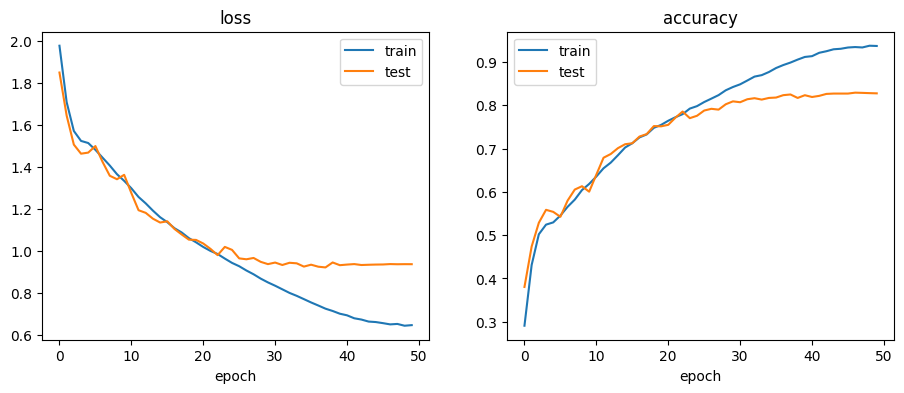

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["test_loss"], label="test")
ax[0].set_title("loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(history["train_acc"], label="train"); ax[1].plot(history["test_acc"], label="test")
ax[1].set_title("accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.show()